In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

%load_ext autoreload
%autoreload 2

data_folder = '/home/shared/generative_models/diffusion_overfit/data'
figs_folder = '/home/tikai103/diffusion_overfit/plots'
save_figs = False
res = 64
model_size = 's'
H = 64  # feature dim
top_folder = f"{data_folder}/gradients/in{res}/edm2-{model_size}"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
def gradient_plot(arrs, titles, ylabel=True, save_as=None):
    for j, (arr, ttl) in enumerate(zip(arrs, titles)):
        plt.subplot(2, len(arrs), len(arrs)*i+j+1)
        plt.imshow(arr, cmap='grey')
        if i == 0:
            plt.title(ttl)
        if j == 0 and ylabel:
            plt.ylabel('val' if val else 'train')
        plt.xticks([], [])
        plt.yticks([], [])

sigma 9: 1.2e+00
sigma 9: 1.2e+00


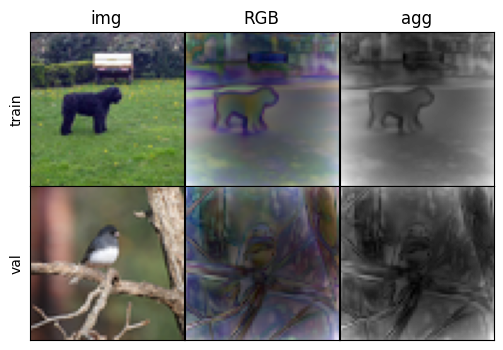

In [7]:
# 1, 20, 26, 29, 30
img_idx = 26
sigma_idx = 7

for sigma_idx in [9]:
    plt.figure(figsize=(6, 4))
    plt.subplots_adjust(wspace=0.0, hspace=0.0)
    # plt.suptitle(f"EDM2-S, IN-64, $\sigma={sigmas.item()}$")
    for i, val in enumerate([False, True]):
        tr_str = 'train' if not val else 'val'
        all_sigmas = sorted([float(s.split('_s')[-1].split('.pt')[0]) for s in os.listdir(top_folder) if f'_{img_idx}_' in s and tr_str in s])
        load_path = f"{top_folder}/corr_scores_{'val' if val else 'train'}_{img_idx}_s{all_sigmas[sigma_idx]:.1e}.pt"
        print(f"sigma {sigma_idx}: {all_sigmas[sigma_idx]:.1e}")
        corr_scores, img, sigmas = torch.load(load_path, weights_only=False)  # [C, H, W], [C, H, W], [1, 1, 1]
        corr_scores = corr_scores.transpose(1,2,0)
        img = img.transpose(1,2,0)
        corr_scores = (corr_scores - corr_scores.min()) / (corr_scores.max() - corr_scores.min())  # Normalize
    
        # arrs = [img, corr_scores[:,:,0], corr_scores[:,:,1], corr_scores[:,:,2], corr_scores, corr_scores.mean(axis=2), img / 255 * corr_scores]
        # titles = ['img', 'red', 'green', 'blue', 'RGB', 'agg', 'combined']
        arrs = [img, corr_scores, corr_scores.mean(axis=2)]
        titles = ['img', 'RGB', 'agg']
        gradient_plot(arrs, titles)
    if save_figs:
        plt.savefig(f"{figs_folder}/figs/eccv2026/gradients/edm2-gradients_CS_both_26_s{all_sigmas[sigma_idx]:.1e}.png", dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

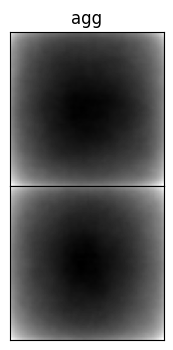

In [17]:
plt.figure(figsize=(8, 4))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
# plt.suptitle(f"EDM2-S, IN-64, $\sigma={sigmas.item()}$")
for i, val in enumerate([False, True]):
    n_imgs = 128
    all_scores = np.zeros((n_imgs, 64, 64, 3))
    all_images = np.zeros((n_imgs, 64, 64, 3))
    for j, img_idx in enumerate(range(n_imgs)):
        load_path = f"{top_folder}/corr_scores_{'val' if val else 'train'}_{img_idx}_s1.0e01.pt"
        corr_scores, img, sigmas = torch.load(load_path, weights_only=False)  # [C, H, W], [C, H, W], [1, 1, 1]
        all_scores[j] = corr_scores.transpose(1,2,0)
        all_images[j] = img.transpose(1,2,0)

    avg_scores = all_scores.mean(axis=0)
    avg_img = all_images.mean(axis=0) / 255
    H, H, C = avg_scores.shape

    avg_scores = (avg_scores - avg_scores.min()) / (avg_scores.max() - avg_scores.min())  # Normalize

    arrs = [avg_scores.mean(axis=2)]
    titles = ['agg']
    gradient_plot(arrs, titles, ylabel=False)

if save_figs:
    plt.savefig(f"{figs_folder}/gradients/edm2-gradients_CS_both_avg.png", dpi=200, bbox_inches='tight')
plt.show()
plt.close()

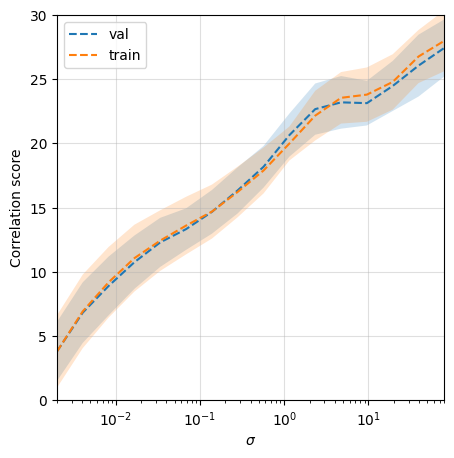

In [19]:
plt.figure(figsize=(5,5))
# plt.suptitle(f"EDM2-S, IN-64, $\sigma={sigmas.item()}$")
for i, val in enumerate([True, False]):
    n_imgs = 32
    n_sigmas = 16
    all_sigmas = all_sigmas = np.logspace(start=np.log10(2e-3), stop=np.log10(80.), num=n_sigmas)
    all_scores = np.zeros((n_imgs, n_sigmas, 64, 64, 3))
    for j, img_idx in enumerate(range(n_imgs)):
        for k, sigma in enumerate(all_sigmas):
            load_path = f"{top_folder}/corr_scores_{'val' if val else 'train'}_{img_idx}_s{sigma.item():.1e}.pt"
            corr_scores = torch.load(load_path, weights_only=False)[0]  # [C, H, W]
            all_scores[j, k] = corr_scores.transpose(1,2,0)

    avg_scores = all_scores.mean(axis=(2,3,4))  # average over pixels and channels
    # avg_scores = all_scores[:, :, 32, 32].mean(axis=-1)  # single pixel, mean over channels
    avg_scores_mean = avg_scores.mean(axis=0)  # average over images
    avg_scores_std = avg_scores.std(axis=0)
    plt.plot(all_sigmas, avg_scores_mean, label=f"val" if val else "train", linestyle="--")
    plt.fill_between(all_sigmas, avg_scores_mean - avg_scores_std, avg_scores_mean + avg_scores_std, alpha=0.2)

    plt.xlabel('$\sigma$')
    plt.ylabel('Correlation score')
    plt.xscale('log')
    plt.grid(alpha=0.4)
    plt.xlim([2e-3, 80])
    plt.ylim([0, 30])
    plt.legend()

if save_figs:
    plt.savefig(f"{figs_folder}/gradients/edm2-gradients_CS-vs-sigma.png", dpi=200, bbox_inches='tight')
plt.show()
plt.close()

In [23]:
plt.figure(figsize=(12,4))
for i, val in enumerate([True, False]):
    load_path = f"{top_folder}/corr_scores_{'val' if val else 'train'}_rand.pt"
    corr_scores, rand_pixels, sigmas = torch.load(load_path, weights_only=False)
    num_steps, bs = corr_scores.shape
    if i == 0:
        plt.suptitle(f"IN-{res}, EDM2-{model_size}, {bs} images across {len(sigmas)} sigmas.")
    
    plt.subplot(1, 2, i+1)
    # Individual plot
    for j in range(0, bs, 1):
        # pixel with its distance from the center
        dist = int(np.abs(rand_pixels[j][0] - H // 2) + np.abs(rand_pixels[j][1] - H // 2))
        ratio = -(dist / 64) + 1
        plt.plot(sigmas.cpu().numpy(), corr_scores[:, j], alpha=0.5, color=(1-ratio,0,ratio), linestyle='-')
    
    plt.xlabel('Sigma')
    plt.ylabel('Correlation score')
    plt.xscale('log')
    plt.title('validation' if val else 'training')
    plt.grid(alpha=0.4)
    plt.ylim([0, 45])

if save_figs:
    plt.savefig(f"{figs_folder}/gradients/edm2-gradients_CS_{'val' if val else 'train'}.png", dpi=200, bbox_inches='tight')
plt.show()
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: '/home/shared/generative_models/diffusion_overfit/data/gradients/in64/edm2-s/corr_scores_val_rand.pt'

<Figure size 1200x400 with 0 Axes>

In [22]:
plt.figure(figsize=(12,4))
# plt.suptitle(f"IN-{res}, EDM2-{model_size}, {bs} images across {len(sigmas)} sigmas.")
for i, val in enumerate([True, False]):
    load_path = f"{top_folder}/corr_scores_{'val' if val else 'train'}_rand.pt"
    corr_scores, rand_pixels, sigmas = torch.load(load_path, weights_only=False)
    num_steps, bs = corr_scores.shape
    
    corr_score_mean = corr_scores.mean(axis=1)  # Average over batch
    corr_score_std = corr_scores.std(axis=1)  # Std over batch
    
    plt.subplot(1, 2, i+1)
   
    # Mean/Std plot
    plt.plot(sigmas.cpu().numpy(), corr_score_mean)
    plt.fill_between(sigmas.cpu().numpy(), corr_score_mean - corr_score_std, corr_score_mean + corr_score_std, alpha=0.2)
    
    plt.xlabel('Sigma')
    plt.ylabel('Correlation score')
    plt.xscale('log')
    plt.title('validation' if val else 'training')
    plt.grid(alpha=0.4)
    plt.ylim([0, 60])

if save_figs:
    plt.savefig(f"{figs_folder}/gradients/edm2-gradients_CS_{'val' if val else 'train'}.png", dpi=200, bbox_inches='tight')
plt.show()
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: '/home/shared/generative_models/diffusion_overfit/data/gradients/in64/edm2-s/corr_scores_val_rand.pt'

<Figure size 1200x400 with 0 Axes>